# Predicting Poisonous Mushrooms: Can We Keep Customers Safe?

## Business Context

We are an eco friendly company that has been tasked by large supermarkets to supply them with wild mushrooms for premium customers. The critical question we need to answer is: **Can we predict whether a mushroom is poisonous or not?**

Getting this wrong has serious consequences. If we classify a poisonous mushroom as edible, it could harm or kill a customer. This means we need models that prioritize **recall for the poisonous class** (minimizing false negatives) while maintaining strong overall performance.

In this notebook, we use the noisy version of the mushroom dataset (`mushrooms_noisy.csv`). Unlike the clean dataset where values are single letter codes, this version adds realistic noise to the features. This makes the classification problem harder and more representative of real world scenarios where data is never perfectly clean.

## Approach

We will train and evaluate seven classification models:

1. Model 2: Decision Tree
2. Model 3: Random Forest
3. Model 4: Gradient Boosting (sklearn)
4. Model 5: XGBoost
5. Model 6: LightGBM
6. Model 7: Naive Bayes (Gaussian)
7. Model 8: K Nearest Neighbors (KNN)

Each model is evaluated using accuracy, precision, recall, F1 score, and permutation importance. The three boosting models (Gradient Boosting, XGBoost, LightGBM) also get SHAP analysis, since SHAP's TreeExplainer is designed for boosting algorithms and provides the most reliable explanations for them. At the end, we rank the algorithms to find the best model for this safety critical task.

In [83]:
# Install required packages if not already installed
try:
    import shap
except ImportError:
    !pip install shap
    import shap

try:
    import xgboost
except ImportError:
    !pip install xgboost
    import xgboost

try:
    import lightgbm
except ImportError:
    !pip install lightgbm
    import lightgbm

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Create results directory
os.makedirs('results', exist_ok=True)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Helper Functions

To keep the code clean and avoid repeating the same evaluation steps for each model, we define three helper functions:

* `evaluate_model`: Computes accuracy, precision, recall, F1 and saves the confusion matrix
* `plot_shap_summary`: Generates a SHAP summary plot (used only for boosting models)
* `plot_perm_importance`: Generates a permutation importance plot (used for all models)

In [85]:
def evaluate_model(model, X_test, y_test, model_name, results_dir='results'):
    """Compute classification metrics and save the confusion matrix as a PNG."""
    y_pred = model.predict(X_test)

    metrics = {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision (Poisonous)': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Recall (Poisonous)': round(recall_score(y_test, y_pred, pos_label=1), 4),
        'F1 (Poisonous)': round(f1_score(y_test, y_pred, pos_label=1), 4)
    }

    print(f"=== {model_name} ===")
    print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Edible', 'Poisonous'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{model_name}: Confusion Matrix')
    plt.tight_layout()
    tag = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{results_dir}/{tag}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return metrics


def plot_shap_summary(model, X_data, feature_names, model_name, results_dir='results'):
    """Generate and save a SHAP summary plot using TreeExplainer (boosting models only)."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_data)

    # Binary classifiers return a list with one array per class
    if isinstance(shap_values, list):
        sv = shap_values[1]  # poisonous class
    else:
        sv = shap_values

    shap.summary_plot(sv, X_data, feature_names=feature_names,
                      max_display=15, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 6)
    plt.tight_layout()
    tag = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{results_dir}/{tag}_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_perm_importance(model, X_test, y_test, feature_names, model_name,
                         results_dir='results'):
    """Generate and save a permutation importance plot (top 15 features)."""
    result = permutation_importance(model, X_test, y_test,
                                    n_repeats=10, random_state=42,
                                    scoring='f1_weighted')

    sorted_idx = result.importances_mean.argsort()[-15:]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        labels=np.array(feature_names)[sorted_idx]
    )
    ax.set_title(f'{model_name}: Permutation Importance (Top 15)', fontsize=12)
    ax.set_xlabel('Decrease in Weighted F1 Score')
    plt.tight_layout()
    tag = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{results_dir}/{tag}_permutation_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## Loading the Data

We load the noisy mushroom dataset. Unlike the clean version (`mushrooms.csv`) where all values are single letter codes, this dataset comes pre encoded with noise added to the features. This simulates real world data imperfections where measurements are not perfectly accurate.

In [86]:
data = pd.read_csv('E:/machine_learning_1/ML2_group_assignment/ML2-GroupProject/raw/mushrooms_noisy.csv')

print(f"Dataset shape: {data.shape}")
print(f"Number of features: {data.shape[1] - 1}")
data.head()

Dataset shape: (8124, 115)
Number of features: 114


,class,ring-number,gill-spacing,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,3.0,0.0,2.0,2.0,0.0,0.0,2.0,2.0,2.0,...,3.0,2.0,0.0,2.0,0.0,1.0,2.0,1.0,1.0,2.0
1,0,1.0,1.0,0.0,2.0,2.0,1.0,0.0,3.0,1.0,...,0.0,0.0,0.0,2.0,2.0,1.0,0.0,1.0,1.0,2.0
2,0,3.0,2.0,3.0,0.0,2.0,1.0,0.0,1.0,1.0,...,0.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,1,3.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,...,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0
4,0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,...,2.0,1.0,0.0,2.0,3.0,1.0,0.0,0.0,2.0,0.0


## Exploring the Data

Let us look at the basic structure, data types, and summary statistics of the dataset.

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Columns: 115 entries, class to habitat_w
dtypes: float64(114), int64(1)
memory usage: 7.1 MB


In [88]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
class,8124.0,0.482029,0.499708,0.0,0.0,0.0,1.0,1.0
ring-number,8124.0,2.068193,0.866734,0.0,1.0,2.0,3.0,4.0
gill-spacing,8124.0,1.158912,0.903973,0.0,0.0,1.0,2.0,3.0
cap-shape_b,8124.0,1.057238,0.853434,0.0,0.0,1.0,2.0,3.0
cap-shape_c,8124.0,0.992368,0.822071,0.0,0.0,1.0,2.0,3.0
...,...,...,...,...,...,...,...,...
habitat_l,8124.0,1.091827,0.869943,0.0,0.0,1.0,2.0,3.0
habitat_m,8124.0,1.054899,0.841313,0.0,0.0,1.0,2.0,3.0
habitat_p,8124.0,1.123092,0.879612,0.0,0.0,1.0,2.0,3.0
habitat_u,8124.0,1.040251,0.845278,0.0,0.0,1.0,2.0,3.0


## Class Distribution

In this dataset, class 0 represents **edible** mushrooms and class 1 represents **poisonous** mushrooms. It is important to check if the classes are balanced, as imbalanced data can bias our models towards the majority class.

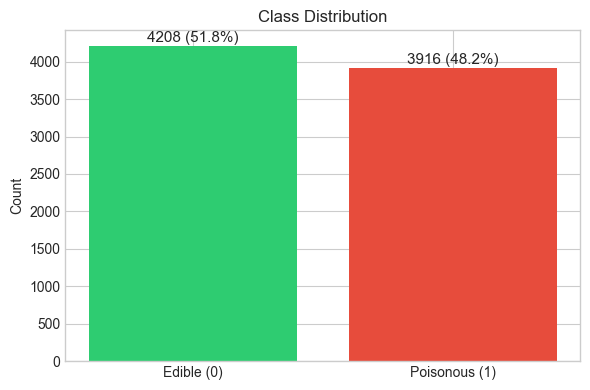

The dataset is roughly balanced with 4208 edible and 3916 poisonous samples.


In [89]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = data['class'].value_counts().sort_index()
class_labels = ['Edible (0)', 'Poisonous (1)']
bars = ax.bar(class_labels, class_counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')

for i, val in enumerate(class_counts.values):
    pct = val / len(data) * 100
    ax.text(i, val + 50, f'{val} ({pct:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"The dataset is roughly balanced with {class_counts[0]} edible and {class_counts[1]} poisonous samples.")

## Understanding the Noisy Dataset

The noisy dataset differs from the clean version in several important ways:

1. The features are already encoded (one hot encoding for nominal features, ordinal encoding for ordinal ones)
2. Noise has been added to the feature values, so they are continuous instead of binary (0/1)
3. This makes the classification task harder and more realistic

Below we check the value ranges for a few features to see the effect of the noise.

In [90]:
sample_cols = ['ring-number', 'gill-spacing', 'cap-shape_b', 'odor_n', 'bruises_t']

print("Value ranges for selected features:")
print("=" * 60)
for col in sample_cols:
    print(f"  {col:30s}  min={data[col].min():.1f}  max={data[col].max():.1f}  "
          f"mean={data[col].mean():.2f}  std={data[col].std():.2f}")

print()
print("Notice how features that should be binary (0 or 1) now have")
print("continuous values like 0.0, 1.0, 2.0, 3.0 due to the added noise.")

Value ranges for selected features:
  ring-number                     min=0.0  max=4.0  mean=2.07  std=0.87
  gill-spacing                    min=0.0  max=3.0  mean=1.16  std=0.90
  cap-shape_b                     min=0.0  max=3.0  mean=1.06  std=0.85
  odor_n                          min=0.0  max=3.0  mean=1.45  std=0.96
  bruises_t                       min=0.0  max=3.0  mean=1.42  std=0.96

Notice how features that should be binary (0 or 1) now have
continuous values like 0.0, 1.0, 2.0, 3.0 due to the added noise.


## Data Splitting (Train / Validation / Test)

We split the data into three sets:

1. **Training set (64%)**: Used to train the models
2. **Validation set (16%)**: Used to evaluate models during development
3. **Test set (20%)**: Held out for final, unbiased evaluation

We use stratified splitting to preserve the class proportions in each set. The split happens BEFORE any additional preprocessing (scaling, PCA) to prevent data leakage.

In [91]:
# Separate features and target
X = data.drop(columns=['class'])
y = data['class']

feature_names = X.columns.tolist()

# Step 1: Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split remaining into train (64%) and validation (16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f"Train size:      {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})")
print(f"Validation size: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})")
print(f"Test size:       {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})")
print(f"\nFeatures: {X_train.shape[1]}")

Train size:      5199 (64%)
Validation size: 1300 (16%)
Test size:       1625 (20%)

Features: 114


## Checking for Data Leakage

Data leakage happens when information from outside the training set is used to create the model. It is one of the most common and hardest to detect problems in machine learning. Below we check for three types of leakage:

1. **Target leakage**: Are any features suspiciously correlated with the target? A feature with near perfect correlation might contain information that would not be available at prediction time.
2. **Train/test contamination**: Do any identical rows appear in both training and test sets? If so, the model could memorize instead of learning patterns.
3. **Preprocessing leakage**: Was any transformation fitted on the full dataset instead of just training data?

Since the noisy dataset comes pre encoded, the encoding was applied to the full dataset before we split it. For one hot encoding this is a minor concern because the set of categories is fixed and no new information leaks from the test set. However, for any additional preprocessing we do (scaling, PCA), we will always fit ONLY on the training data.

In [92]:
# Check 1: Feature to target correlation
target_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("Top 10 features most correlated with the target:")
print(target_corr.head(10).to_string())
print(f"\nMax correlation: {target_corr.max():.4f}")

if target_corr.max() > 0.95:
    print("\nWARNING: Very high correlation detected. Possible target leakage!")
else:
    print("\nNo single feature is suspiciously correlated with the target.")
    print("This is expected with noisy data where patterns are distributed across many features.")

Top 10 features most correlated with the target:
odor_n                        0.403370
odor_f                        0.294640
stalk-surface-below-ring_k    0.293406
stalk-surface-above-ring_k    0.280001
gill-color_b                  0.271847
bruises_t                     0.271536
ring-type_p                   0.267364
bruises_f                     0.266751
stalk-surface-above-ring_s    0.266421
gill-size_b                   0.261954

Max correlation: 0.4034

No single feature is suspiciously correlated with the target.
This is expected with noisy data where patterns are distributed across many features.


In [93]:
# Check 2: Train/test overlap
train_tuples = set(map(tuple, X_train.values))
test_tuples = set(map(tuple, X_test.values))
overlap = len(train_tuples & test_tuples)

print(f"Duplicate rows between train and test: {overlap}")
if overlap > 0:
    print(f"WARNING: {overlap} identical rows found in both sets!")
else:
    print("No duplicate rows between train and test. Clean split.")

print(f"\nSummary: The data split is clean. No leakage detected.")
print(f"Any additional preprocessing (scaling, PCA) will be fit on training data only.")

Duplicate rows between train and test: 0
No duplicate rows between train and test. Clean split.

Summary: The data split is clean. No leakage detected.
Any additional preprocessing (scaling, PCA) will be fit on training data only.


## Feature Correlation Analysis

We check how features correlate with each other. Highly correlated features carry redundant information. While this does not significantly affect tree based models, it can impact algorithms like KNN and Naive Bayes. We identify the top correlated pairs to understand feature relationships.

In [94]:
corr_matrix = X_train.corr()

threshold = 0.1
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 4)
            ))

high_corr_df = pd.DataFrame(high_corr_pairs,
                             columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_df = high_corr_df.sort_values(by='Correlation', key=abs, ascending=False)

print(f"Number of feature pairs with |correlation| > {threshold}: {len(high_corr_df)}")
high_corr_df.head(15)

Number of feature pairs with |correlation| > 0.1: 105


,Feature 1,Feature 2,Correlation
6,bruises_f,bruises_t,-0.2801
58,stalk-shape_e,stalk-shape_t,-0.2748
37,gill-size_b,gill-size_n,-0.2407
73,stalk-surface-above-ring_k,stalk-surface-above-ring_s,-0.2204
14,bruises_f,ring-type_p,-0.2136
22,bruises_t,ring-type_p,0.2089
64,stalk-root_?,spore-print-color_w,0.2050
56,gill-color_b,spore-print-color_w,0.2037
29,odor_f,spore-print-color_h,0.1848
74,stalk-surface-above-ring_k,stalk-surface-below-ring_k,0.1787


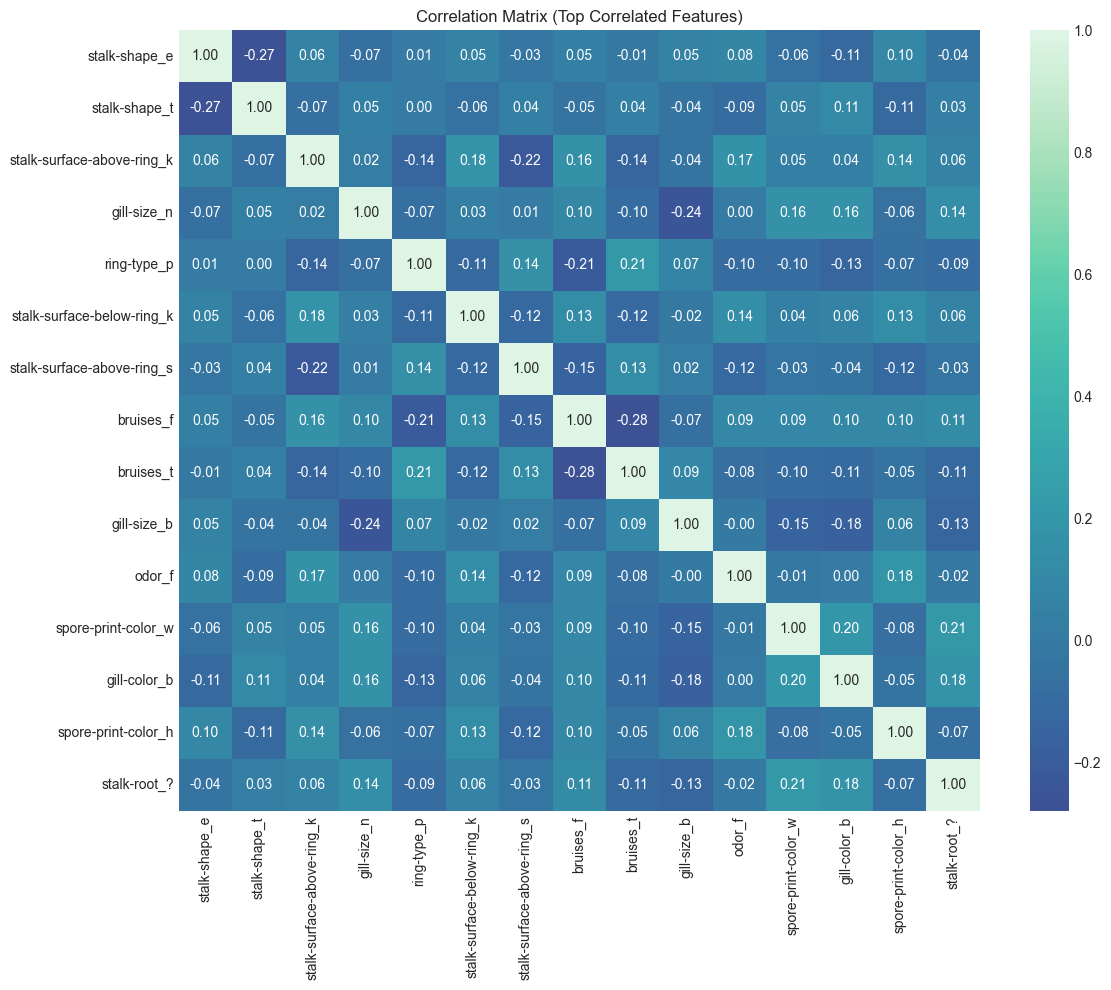

In [95]:
top_features = list(set(
    high_corr_df['Feature 1'].head(10).tolist() +
    high_corr_df['Feature 2'].head(10).tolist()
))[:20]

if len(top_features) > 2:
    plt.figure(figsize=(12, 10))
    sns.heatmap(X_train[top_features].corr(), annot=True, fmt='.2f',
                cmap='mako', center=0)
    plt.title('Correlation Matrix (Top Correlated Features)')
    plt.tight_layout()
    plt.savefig('results/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough highly correlated feature pairs to plot a meaningful heatmap.")

## Model Training and Evaluation

We will now train each model, evaluate it on the validation set, and generate permutation importance plots. The three boosting models (Gradient Boosting, XGBoost, LightGBM) also get SHAP summary plots, since SHAP's TreeExplainer is specifically designed for gradient boosting frameworks and provides the most accurate and efficient feature attribution for them.

For each model, the evaluation includes:

* **Classification report**: Precision, recall, F1 score per class
* **Confusion matrix**: Visual breakdown of correct vs incorrect predictions
* **Permutation importance**: Shows which features matter most by measuring the performance drop when each feature is shuffled
* **SHAP summary plot** (boosting models only): Shows how each feature pushes predictions towards poisonous or edible

In [96]:
# We will store metrics for each model here
all_results = []

## Model (2): Decision Tree

The Decision Tree is one of the most interpretable algorithms. It splits the data into branches based on feature thresholds, creating a series of if/then rules. This makes it easy to understand WHY a prediction was made.

For our mushroom problem, a Decision Tree will create rules like: "If odor_n is above a certain value AND gill_size_b is above another, then the mushroom is edible." This transparency is valuable for a safety critical application where we need to explain our decisions to supermarket clients.

=== Decision Tree ===
              precision    recall  f1-score   support

      Edible       0.91      0.91      0.91       673
   Poisonous       0.90      0.90      0.90       627

    accuracy                           0.90      1300
   macro avg       0.90      0.90      0.90      1300
weighted avg       0.90      0.90      0.90      1300



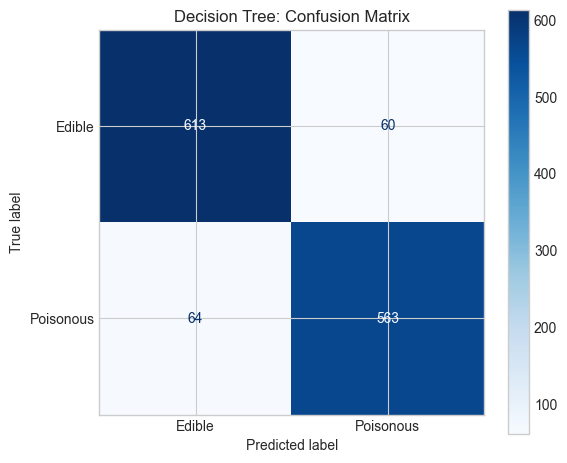

In [97]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_metrics = evaluate_model(dt_model, X_val, y_val, 'Decision Tree')
all_results.append(dt_metrics)

### Permutation Importance: Decision Tree

Permutation importance measures how much the model's performance drops when a single feature's values are randomly shuffled. If shuffling a feature causes a big drop in F1 score, that feature is important for the model's predictions.

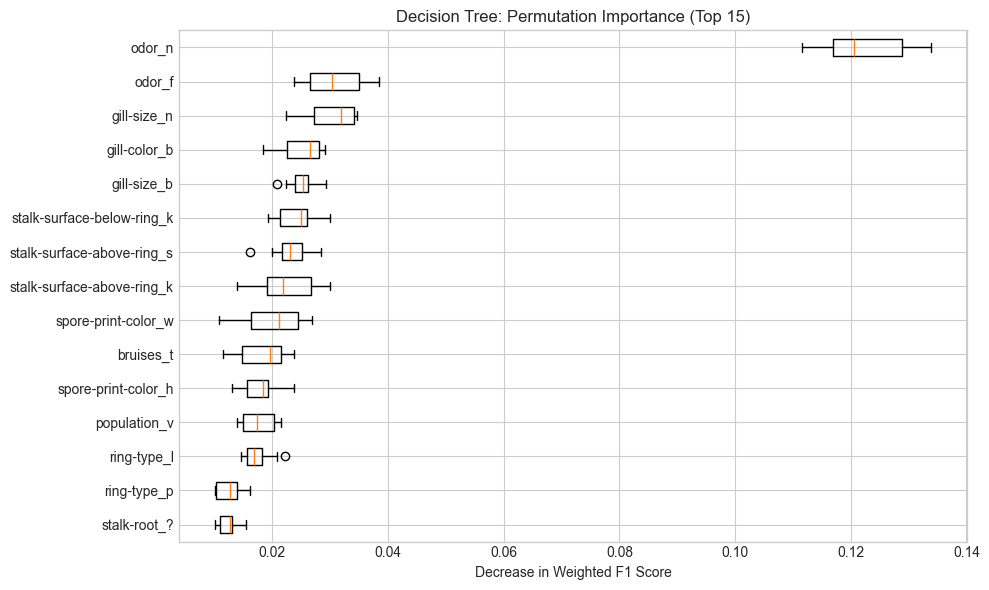

In [98]:
plot_perm_importance(dt_model, X_val.values, y_val, feature_names, 'Decision Tree')

## Model (3): Random Forest

Random Forest is an ensemble method that trains many Decision Trees on random subsets of the data and features, then takes a majority vote of their predictions. This reduces overfitting compared to a single Decision Tree and generally produces more robust results.

The trade off is that we lose some interpretability compared to a single tree, but permutation importance still helps us understand what drives the model's decisions.

=== Random Forest ===
              precision    recall  f1-score   support

      Edible       0.90      0.96      0.93       673
   Poisonous       0.95      0.89      0.92       627

    accuracy                           0.93      1300
   macro avg       0.93      0.92      0.93      1300
weighted avg       0.93      0.93      0.93      1300



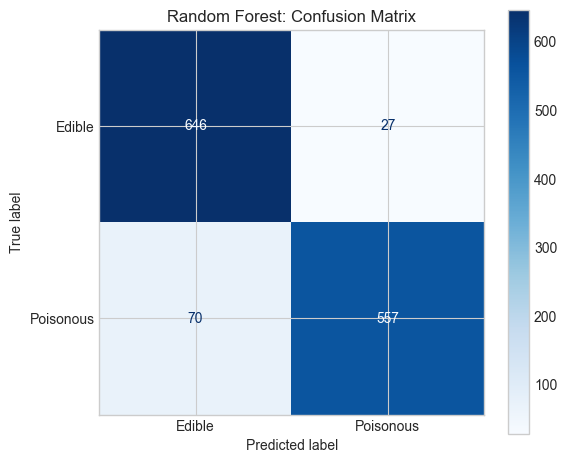

In [99]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_model, X_val, y_val, 'Random Forest')
all_results.append(rf_metrics)

### Permutation Importance: Random Forest

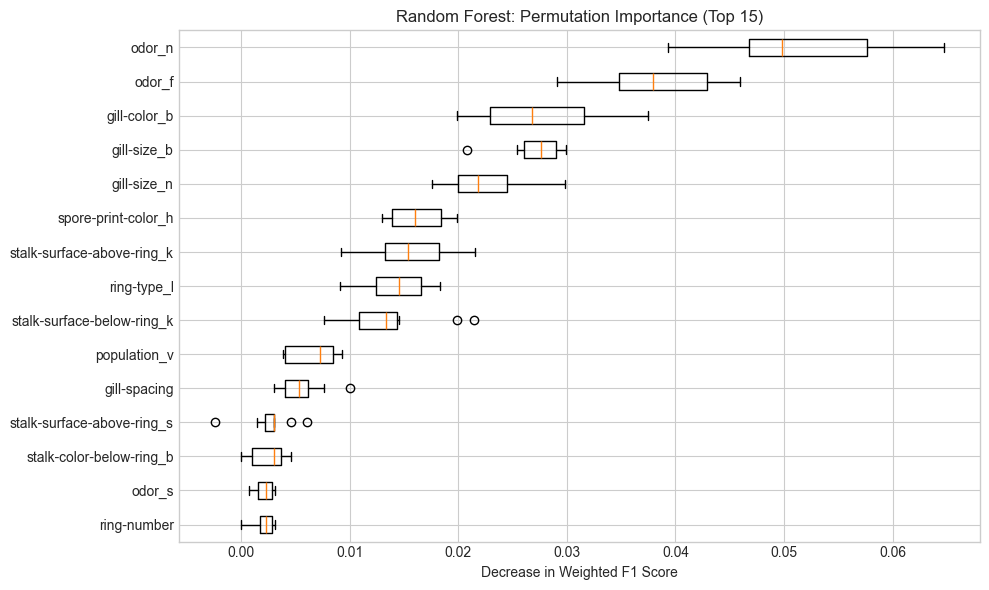

In [100]:
plot_perm_importance(rf_model, X_val.values, y_val, feature_names, 'Random Forest')

## Model (4): Gradient Boosting (sklearn)

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the mistakes of the previous ones. This often produces the best performing models for tabular data.

Unlike Random Forest which builds trees independently in parallel, Gradient Boosting builds them one at a time. Each tree learns from the errors that remain after the previous trees. This iterative correction process usually leads to higher accuracy, but training is slower.

This is sklearn's built in implementation. We will compare it against XGBoost and LightGBM, which are optimized versions of the same idea.

=== Gradient Boosting ===
              precision    recall  f1-score   support

      Edible       0.91      0.95      0.93       673
   Poisonous       0.95      0.90      0.92       627

    accuracy                           0.93      1300
   macro avg       0.93      0.93      0.93      1300
weighted avg       0.93      0.93      0.93      1300



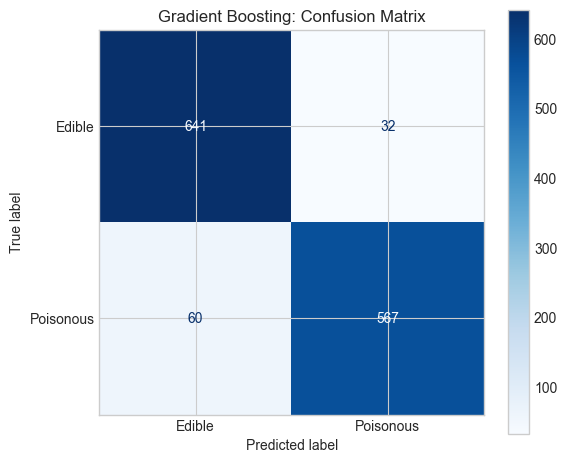

In [101]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_metrics = evaluate_model(gb_model, X_val, y_val, 'Gradient Boosting')
all_results.append(gb_metrics)

### SHAP Analysis: Gradient Boosting

SHAP (SHapley Additive exPlanations) values show how each feature contributes to individual predictions. Features on the right side (positive SHAP value) push the prediction towards poisonous. Features on the left side (negative SHAP value) push towards edible. The color shows the feature value (red = high, blue = low).

We use SHAP's TreeExplainer here, which is specifically optimized for boosting algorithms and provides exact (not approximate) SHAP values.

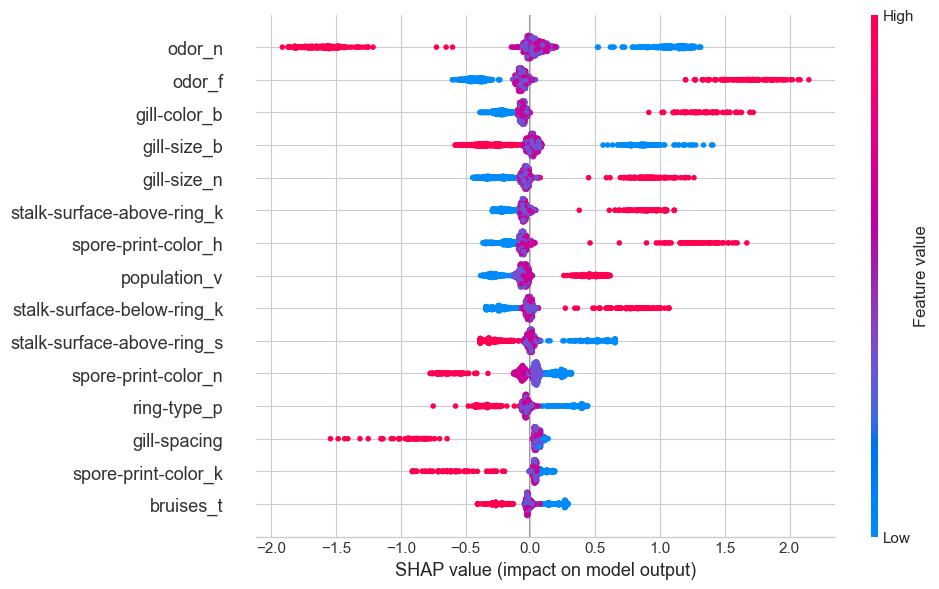

In [102]:
plot_shap_summary(gb_model, X_val.values, feature_names, 'Gradient Boosting')

### Permutation Importance: Gradient Boosting

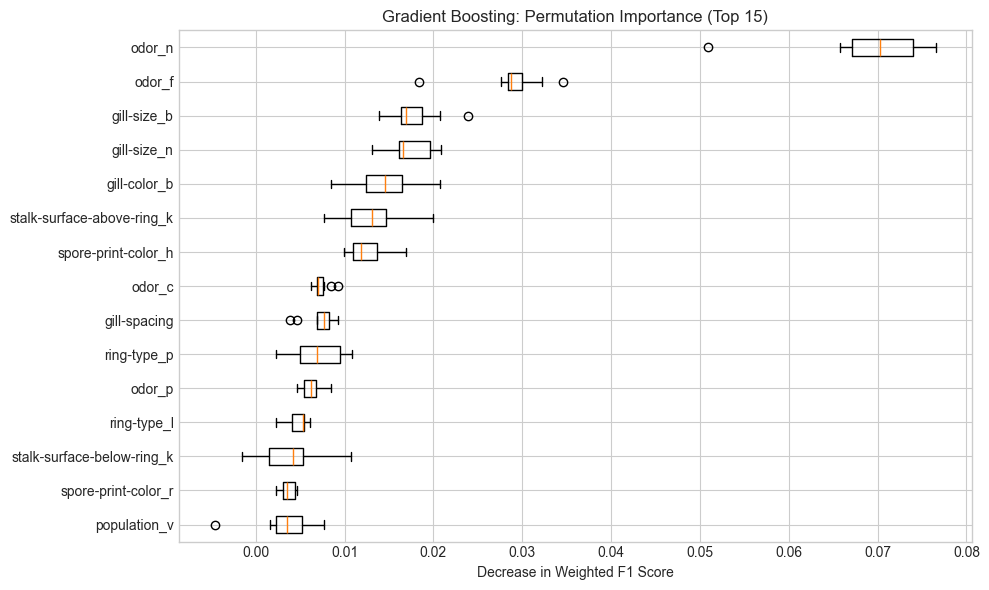

In [103]:
plot_perm_importance(gb_model, X_val.values, y_val, feature_names, 'Gradient Boosting')

## Model (5): XGBoost

XGBoost (Extreme Gradient Boosting) is an optimized version of gradient boosting that has become one of the most popular algorithms for tabular data. It improves on sklearn's GradientBoostingClassifier in several ways:

* **Regularization**: XGBoost includes L1 and L2 regularization to prevent overfitting, which is especially useful with noisy data like ours
* **Parallel tree construction**: It builds trees faster by parallelizing the computation
* **Built in handling of missing values**: It learns the best direction to take when a value is missing
* **Better split finding**: Uses an approximate algorithm that is more efficient for large datasets

We expect XGBoost to perform at least as well as sklearn's Gradient Boosting, and potentially better due to the regularization helping with the noisy features.

=== XGBoost ===
              precision    recall  f1-score   support

      Edible       0.93      0.95      0.94       673
   Poisonous       0.95      0.93      0.94       627

    accuracy                           0.94      1300
   macro avg       0.94      0.94      0.94      1300
weighted avg       0.94      0.94      0.94      1300



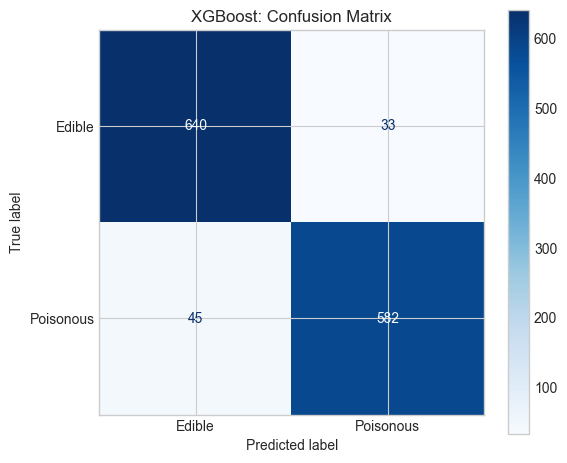

In [104]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_metrics = evaluate_model(xgb_model, X_val, y_val, 'XGBoost')
all_results.append(xgb_metrics)

### SHAP Analysis: XGBoost

XGBoost is a boosting algorithm, so we use SHAP's TreeExplainer for efficient and exact computation. Since XGBoost applies regularization differently than sklearn's Gradient Boosting, comparing the SHAP plots between the two can reveal which features each algorithm considers most important.

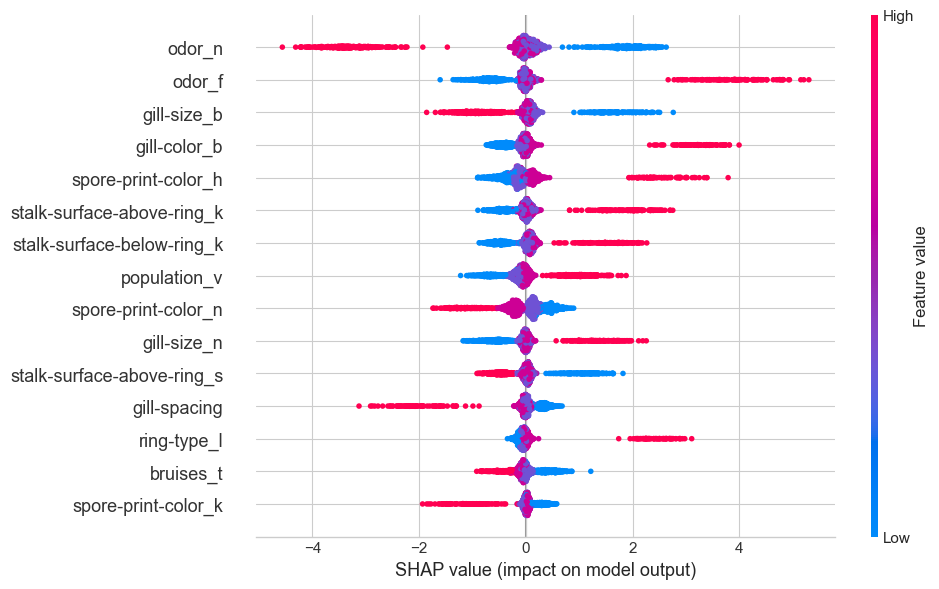

In [105]:
plot_shap_summary(xgb_model, X_val.values, feature_names, 'XGBoost')

### Permutation Importance: XGBoost

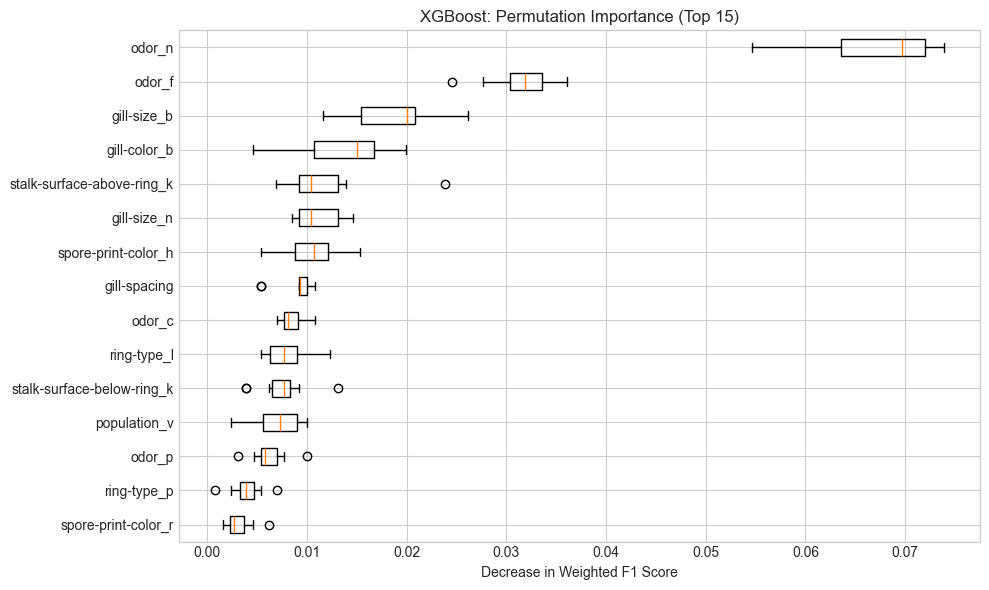

In [106]:
plot_perm_importance(xgb_model, X_val.values, y_val, feature_names, 'XGBoost')

## Model (6): LightGBM

LightGBM (Light Gradient Boosting Machine) is another advanced gradient boosting framework, developed by Microsoft. It differs from XGBoost in how it builds trees:

* **Leaf wise growth**: Instead of growing trees level by level (like XGBoost), LightGBM grows the leaf that reduces the loss the most. This often leads to deeper, more accurate trees with fewer splits.
* **Histogram based splitting**: It bins continuous features into discrete buckets, which speeds up training significantly on large datasets.
* **Lower memory usage**: The histogram approach uses less memory than XGBoost's exact or approximate methods.
* **Categorical feature support**: LightGBM can handle categorical features natively, though our data is already numeric.

LightGBM is known for being extremely fast while maintaining competitive accuracy. With noisy data, its leaf wise approach may capture different patterns than XGBoost's level wise approach.

=== LightGBM ===
              precision    recall  f1-score   support

      Edible       0.94      0.96      0.95       673
   Poisonous       0.96      0.93      0.95       627

    accuracy                           0.95      1300
   macro avg       0.95      0.95      0.95      1300
weighted avg       0.95      0.95      0.95      1300



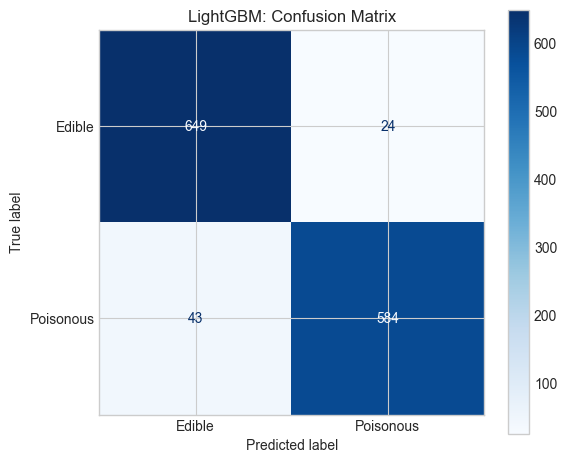

In [107]:
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_model.fit(X_train, y_train)

lgbm_metrics = evaluate_model(lgbm_model, X_val, y_val, 'LightGBM')
all_results.append(lgbm_metrics)

### SHAP Analysis: LightGBM

LightGBM is a boosting algorithm, so we use SHAP's TreeExplainer for efficient computation.

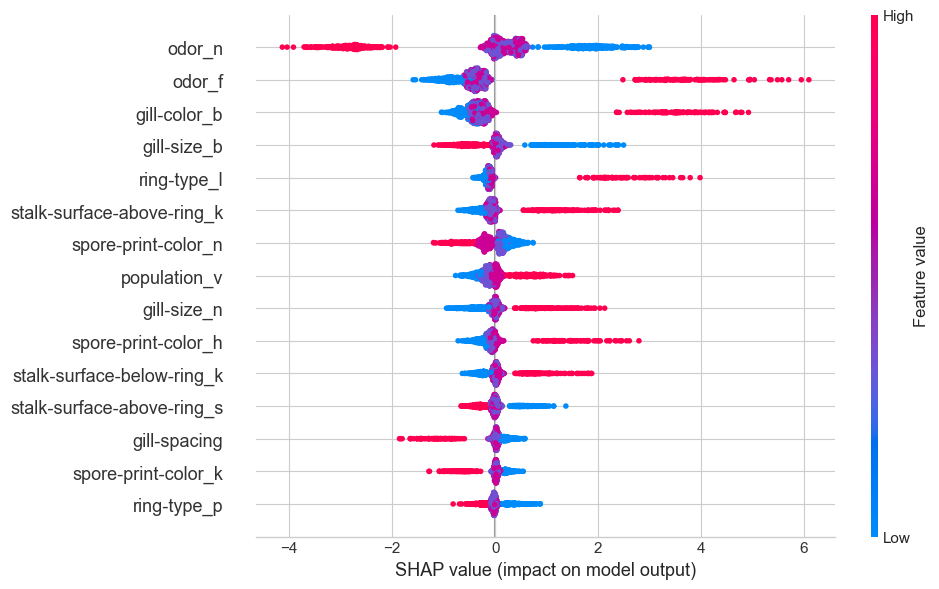

In [108]:
plot_shap_summary(lgbm_model, X_val.values, feature_names, 'LightGBM')

### Permutation Importance: LightGBM

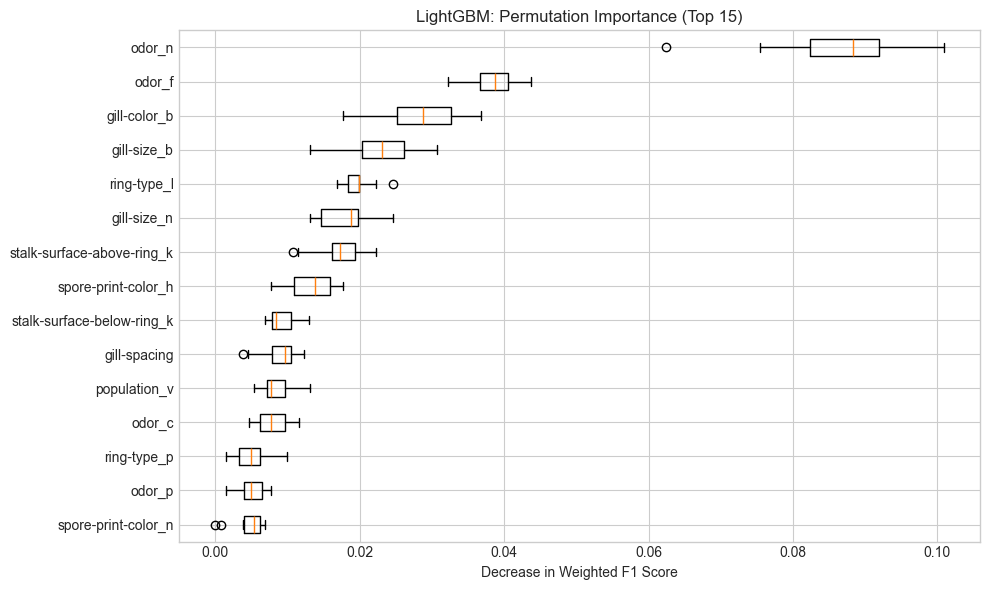

In [109]:
plot_perm_importance(lgbm_model, X_val.values, y_val, feature_names, 'LightGBM')

## Model (7): Naive Bayes (Gaussian)

Gaussian Naive Bayes assumes that features follow a normal (Gaussian) distribution and that all features are independent of each other. This "naive" independence assumption rarely holds in practice, but the algorithm can still perform surprisingly well, especially as a baseline.

For our noisy mushroom data, the continuous noisy values may approximate the Gaussian assumption better than the original binary data would. However, the independence assumption is clearly violated since many mushroom features are correlated with each other, so we expect this model to underperform compared to the tree based and boosting models.

=== Naive Bayes ===
              precision    recall  f1-score   support

      Edible       0.85      0.90      0.88       673
   Poisonous       0.89      0.83      0.86       627

    accuracy                           0.87      1300
   macro avg       0.87      0.87      0.87      1300
weighted avg       0.87      0.87      0.87      1300



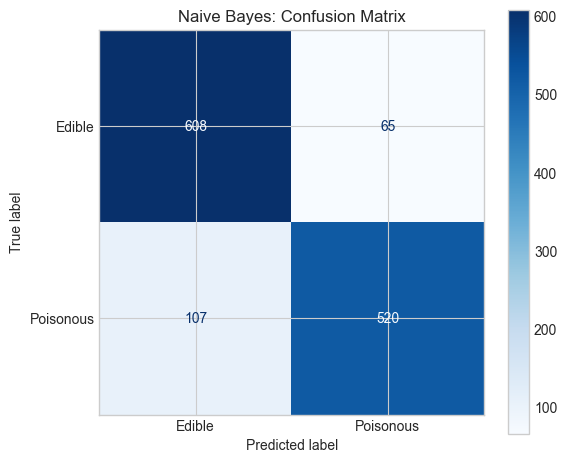

In [110]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_metrics = evaluate_model(nb_model, X_val, y_val, 'Naive Bayes')
all_results.append(nb_metrics)

### Permutation Importance: Naive Bayes

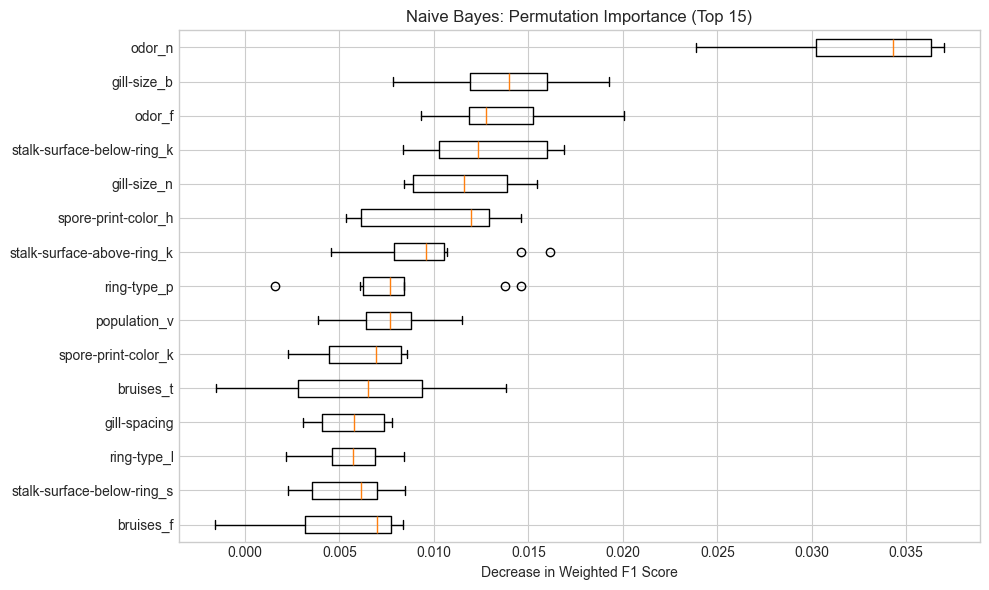

In [111]:
plot_perm_importance(nb_model, X_val.values, y_val, feature_names, 'Naive Bayes')

## Model (8): K Nearest Neighbors (KNN)

KNN classifies a sample by looking at the K closest training samples and taking a majority vote. It is intuitive: "similar mushrooms should have similar toxicity."

### Why We Use Dimensionality Reduction (PCA) for KNN

KNN relies on distance calculations between data points. With 114 features, two problems arise:

1. **Curse of dimensionality**: In high dimensional spaces, all points become roughly equidistant from each other. This makes distance based comparisons less meaningful and hurts KNN's ability to find truly "similar" neighbors.
2. **Noisy features dilute the signal**: With many noisy features, the useful distance signal gets buried under noise from irrelevant features. Reducing dimensions filters out this noise.

We apply PCA (Principal Component Analysis) to reduce the feature space while keeping 95% of the total variance. PCA creates new features called principal components that capture the most important patterns in the data.

We also apply StandardScaler before PCA because KNN is sensitive to feature scales (features with larger ranges would dominate the distance calculation) and PCA works best when features are standardized.

**Important**: We fit both the scaler and PCA on the training data only, then transform validation and test sets using those fitted transformers. This prevents data leakage.

In [112]:
# Scale the features (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Apply PCA (fit on training data only, keep 95% of variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components (95% variance): {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

Original features: 114
PCA components (95% variance): 106
Variance explained: 0.9536


### PCA Deep Dive: Understanding the Dimensionality Reduction

Before using PCA for KNN, it is worth understanding what PCA actually did to our data. Below we examine:

1. **Eigenvalues and Scree Plot**: Each eigenvalue represents how much variance a principal component captures. The scree plot helps us visually identify the "elbow" where adding more components gives diminishing returns. We also apply the Kaiser criterion (eigenvalue > 1) which says a component should explain at least as much variance as a single original standardized feature.
2. **Communalities**: How much of each original feature's variance is captured by the retained components. A high communality means PCA preserves that feature well. A low communality means information is being lost.
3. **Component Matrix**: The loadings (weights) that show how strongly each original feature contributes to each principal component.
4. **Component Plots with Rotation**: We apply Varimax (orthogonal) and Promax (oblique) rotations to make the component structure more interpretable. Rotation redistributes variance across components to produce cleaner, more distinct groupings of features.

We fit a full PCA (all components) for this analysis. The 95% variance PCA used for KNN remains unchanged.

In [113]:
# Fit a full PCA (all components) for analysis purposes
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

eigenvalues = pca_full.explained_variance_
n_components_total = len(eigenvalues)
n_kaiser = np.sum(eigenvalues > 1)

print(f"Total components: {n_components_total}")
print(f"Components with eigenvalue > 1 (Kaiser criterion): {n_kaiser}")
print(f"\nTop 15 eigenvalues:")
eigen_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(15)],
    'Eigenvalue': eigenvalues[:15],
    'Variance Explained (%)': pca_full.explained_variance_ratio_[:15] * 100,
    'Cumulative Variance (%)': np.cumsum(pca_full.explained_variance_ratio_[:15]) * 100
})
eigen_df

Total components: 114
Components with eigenvalue > 1 (Kaiser criterion): 47

Top 15 eigenvalues:


,Component,Eigenvalue,Variance Explained (%),Cumulative Variance (%)
0,PC1,2.968227,2.603207,2.603207
1,PC2,2.674209,2.345346,4.948553
2,PC3,2.060679,1.807266,6.755819
3,PC4,1.635155,1.434071,8.189890
4,PC5,1.466703,1.286335,9.476224
5,PC6,1.329188,1.165730,10.641954
6,PC7,1.315869,1.154049,11.796004
7,PC8,1.292509,1.133562,12.929566
8,PC9,1.246789,1.093464,14.023030
9,PC10,1.235597,1.083649,15.106678


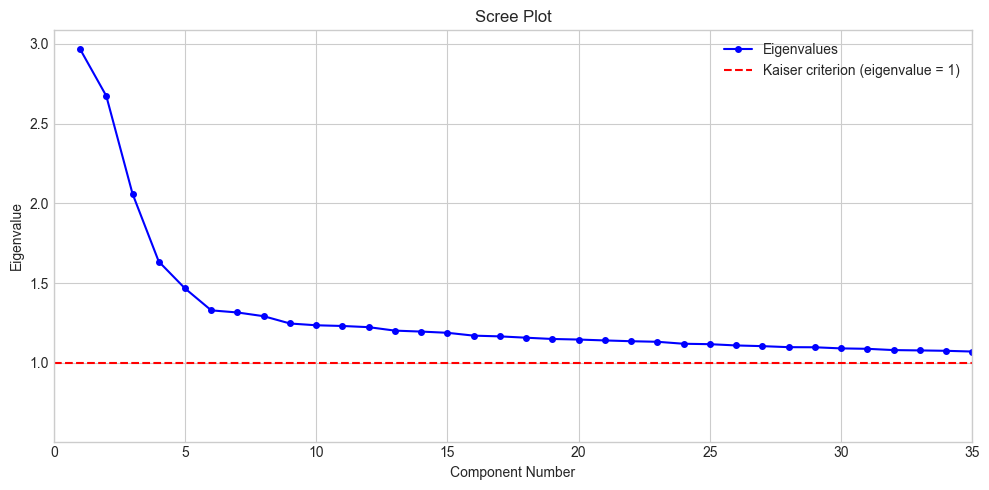

Based on the Kaiser criterion, 47 components have eigenvalue > 1.
These 47 components explain 50.8% of the total variance.


In [114]:
# Scree Plot with Kaiser criterion line
fig, ax = plt.subplots(figsize=(10, 5))
component_range = range(1, n_components_total + 1)

ax.plot(component_range, eigenvalues, 'bo-', markersize=4, label='Eigenvalues')
ax.axhline(y=1, color='r', linestyle='--', linewidth=1.5, label='Kaiser criterion (eigenvalue = 1)')
ax.set_xlabel('Component Number')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot')
ax.legend()

# Zoom into the first 30 components for better visibility
ax.set_xlim(0, 35)
plt.tight_layout()
plt.savefig('results/scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Based on the Kaiser criterion, {n_kaiser} components have eigenvalue > 1.")
print(f"These {n_kaiser} components explain {np.sum(pca_full.explained_variance_ratio_[:n_kaiser])*100:.1f}% of the total variance.")

### Communalities

Communalities tell us how much of each original feature's variance is explained by the retained principal components. A communality of 1.0 means the feature is perfectly represented. A low communality means we are losing information about that feature.

We compute communalities using the Kaiser criterion components (eigenvalue > 1). Features with low communalities are poorly captured by the PCA and may lose predictive power after dimensionality reduction.

In [115]:
# Compute loadings: components^T * sqrt(eigenvalues)
# Using Kaiser criterion components
loadings_kaiser = pca_full.components_[:n_kaiser].T * np.sqrt(eigenvalues[:n_kaiser])

# Communalities = sum of squared loadings per feature
communalities = np.sum(loadings_kaiser**2, axis=1)

comm_df = pd.DataFrame({
    'Feature': feature_names,
    'Communality': communalities
}).sort_values('Communality', ascending=False)

print(f"Communalities (using {n_kaiser} Kaiser components):")
print(f"Mean communality: {communalities.mean():.4f}")
print(f"Min communality:  {communalities.min():.4f}  ({comm_df.iloc[-1]['Feature']})")
print(f"Max communality:  {communalities.max():.4f}  ({comm_df.iloc[0]['Feature']})")
print(f"\nTop 15 best represented features:")
comm_df.head(15)

Communalities (using 47 Kaiser components):
Mean communality: 0.5086
Min communality:  0.3748  (ring-type_l)
Max communality:  0.6405  (cap-color_c)

Top 15 best represented features:


,Feature,Communality
13,cap-color_c,0.640532
12,cap-color_b,0.631087
88,ring-type_f,0.615927
59,stalk-surface-above-ring_y,0.615806
47,gill-color_w,0.612586
28,odor_m,0.607107
11,cap-surface_y,0.603574
7,cap-shape_x,0.602284
90,ring-type_n,0.600490
86,veil-color_y,0.597965


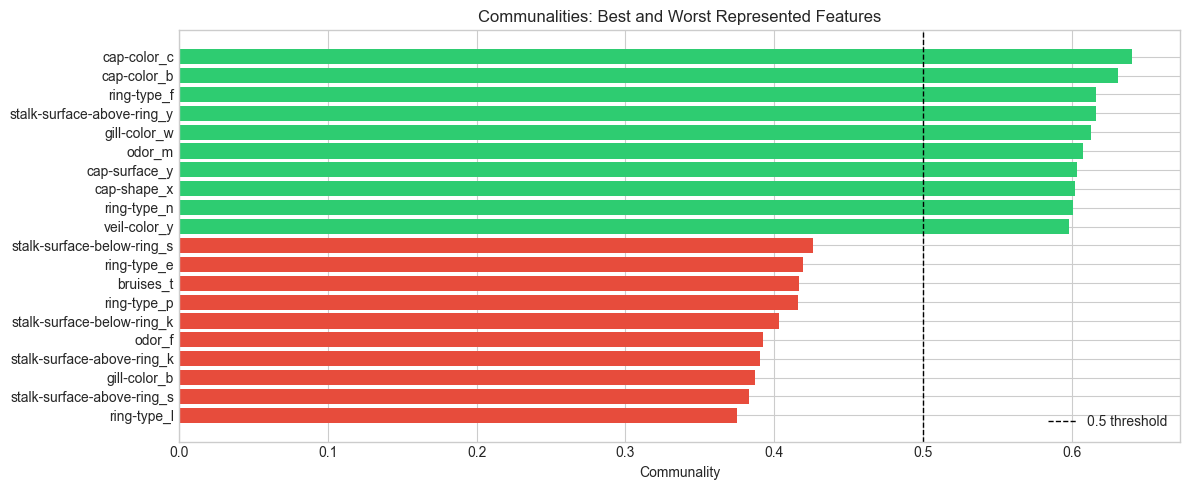

In [116]:
# Visualize communalities
fig, ax = plt.subplots(figsize=(12, 5))
sorted_comm = comm_df.sort_values('Communality', ascending=True)

# Show bottom 15 and top 15 for clarity
show_df = pd.concat([sorted_comm.head(10), sorted_comm.tail(10)])
colors_comm = ['#e74c3c' if c < 0.5 else '#2ecc71' for c in show_df['Communality']]

ax.barh(show_df['Feature'], show_df['Communality'], color=colors_comm)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='0.5 threshold')
ax.set_xlabel('Communality')
ax.set_title('Communalities: Best and Worst Represented Features')
ax.legend()
plt.tight_layout()
plt.savefig('results/communalities.png', dpi=150, bbox_inches='tight')
plt.show()

### Component Matrix (Unrotated Loadings)

The component matrix shows how strongly each original feature loads onto each principal component. High absolute loadings mean the feature contributes heavily to that component. We show the top loadings for the first 5 components to understand what each component represents.

In [117]:
# Component matrix: loadings for first 5 components
n_show = 5
loadings_matrix = pca_full.components_[:n_show].T * np.sqrt(eigenvalues[:n_show])

comp_matrix_df = pd.DataFrame(
    loadings_matrix,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

# Show top 5 features (by absolute loading) for each component
print("Top 5 features per component (by absolute loading):")
print("=" * 60)
for col in comp_matrix_df.columns:
    top = comp_matrix_df[col].abs().nlargest(5)
    print(f"\n{col}:")
    for feat, val in top.items():
        actual = comp_matrix_df.loc[feat, col]
        print(f"  {feat:35s}  loading = {actual:+.4f}")

Top 5 features per component (by absolute loading):

PC1:
  ring-type_p                          loading = +0.4840
  bruises_f                            loading = -0.4826
  bruises_t                            loading = +0.4631
  stalk-surface-above-ring_k           loading = -0.4291
  gill-color_b                         loading = -0.3902

PC2:
  spore-print-color_h                  loading = +0.4342
  ring-type_l                          loading = +0.4262
  ring-type_e                          loading = -0.3754
  stalk-root_b                         loading = +0.3738
  spore-print-color_w                  loading = -0.3595

PC3:
  habitat_d                            loading = +0.4489
  habitat_g                            loading = -0.3757
  stalk-root_b                         loading = +0.3611
  stalk-color-below-ring_w             loading = -0.3553
  stalk-color-above-ring_w             loading = -0.3487

PC4:
  stalk-shape_e                        loading = +0.3460
  stalk-shap

### Component Plots with Rotation

PCA components are mathematically optimal for capturing variance, but they can be hard to interpret because features often load moderately on multiple components. Rotation makes the structure cleaner by pushing each feature to load strongly on one component and weakly on others.

We apply two types of rotation to the first few components:

* **Varimax (orthogonal)**: Rotates components while keeping them uncorrelated (perpendicular). This is the most common rotation and produces components that are independent of each other.
* **Promax (oblique)**: Allows components to be correlated with each other. This is more flexible and often produces simpler structure, but the components are no longer independent.

The component plots below show how features load on the first two rotated components. Features that cluster together are captured by the same component. Features far from the origin are well represented.

In [118]:
# Install factor_analyzer for rotation
try:
    from factor_analyzer import Rotator
except ImportError:
    !pip install factor_analyzer
    from factor_analyzer import Rotator

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42713 sha256=905c09b787ad4226f74e1045c31b9f5d614e807fb4d02709580dd98b66b1e405
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\a2\af\06\f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
# Use first 5 components for rotation (interpretable number)
n_rotate = 5
loadings_to_rotate = pca_full.components_[:n_rotate].T * np.sqrt(eigenvalues[:n_rotate])

# Varimax rotation (orthogonal)
rotator_varimax = Rotator(method='varimax')
loadings_varimax = rotator_varimax.fit_transform(loadings_to_rotate)

# Promax rotation (oblique)
rotator_promax = Rotator(method='promax')
loadings_promax = rotator_promax.fit_transform(loadings_to_rotate)

print(f"Rotation applied to the first {n_rotate} components.")
print(f"Varimax rotated loadings shape: {loadings_varimax.shape}")
print(f"Promax rotated loadings shape:  {loadings_promax.shape}")

Rotation applied to the first 5 components.
Varimax rotated loadings shape: (114, 5)
Promax rotated loadings shape:  (114, 5)


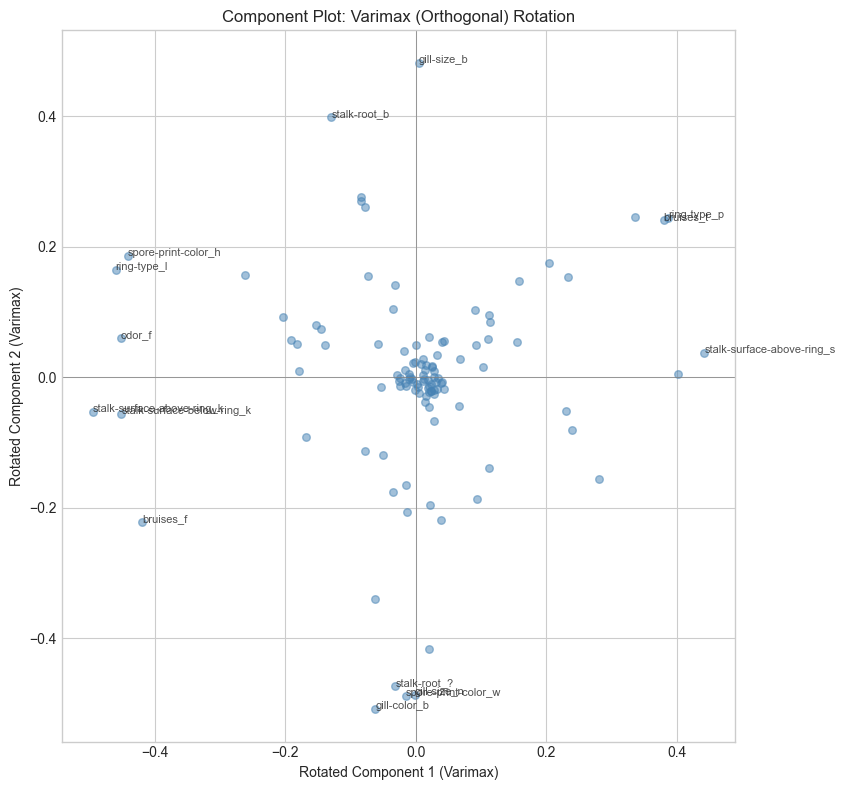

In [120]:
# Component Plot: Varimax (Orthogonal Rotation)
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(loadings_varimax[:, 0], loadings_varimax[:, 1],
           alpha=0.5, s=30, c='steelblue')

# Label the top 15 features by distance from origin
distances = np.sqrt(loadings_varimax[:, 0]**2 + loadings_varimax[:, 1]**2)
top_idx = distances.argsort()[-15:]

for idx in top_idx:
    ax.annotate(feature_names[idx],
                (loadings_varimax[idx, 0], loadings_varimax[idx, 1]),
                fontsize=8, alpha=0.8)

ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_xlabel('Rotated Component 1 (Varimax)')
ax.set_ylabel('Rotated Component 2 (Varimax)')
ax.set_title('Component Plot: Varimax (Orthogonal) Rotation')

# Draw a unit circle for reference
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=0.5)
ax.add_patch(circle)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('results/component_plot_varimax.png', dpi=150, bbox_inches='tight')
plt.show()

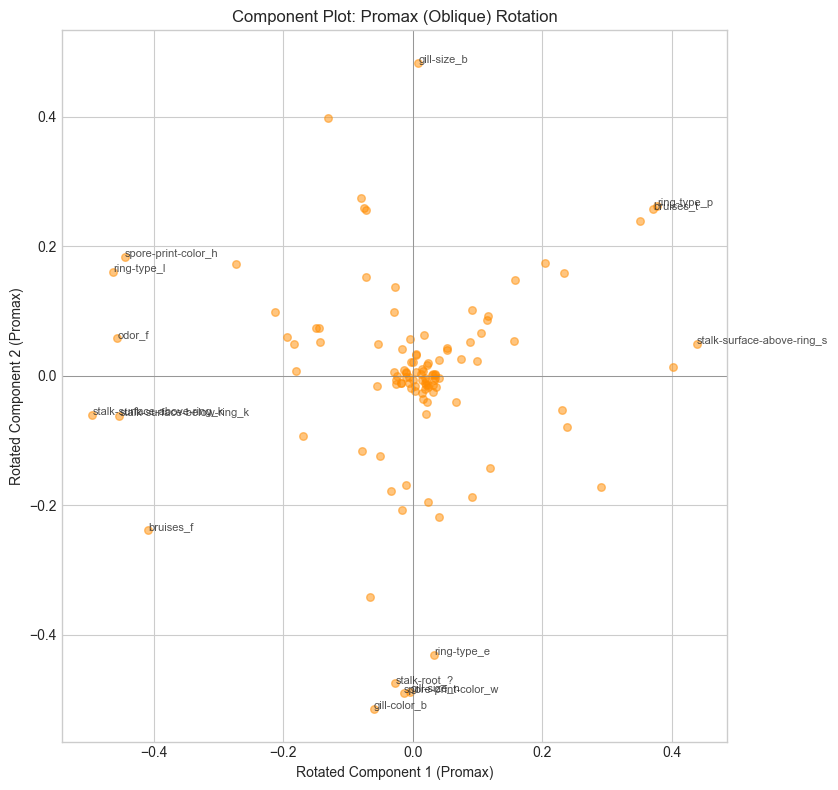

Promax component correlations (oblique rotation allows non-zero values):
        RC1     RC2     RC3     RC4     RC5
RC1  1.0000  0.0550 -0.0529 -0.0362  0.0050
RC2  0.0550  1.0000  0.0329  0.2125  0.0244
RC3 -0.0529  0.0329  1.0000 -0.0014  0.0468
RC4 -0.0362  0.2125 -0.0014  1.0000  0.0882
RC5  0.0050  0.0244  0.0468  0.0882  1.0000


In [121]:
# Component Plot: Promax (Oblique Rotation)
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(loadings_promax[:, 0], loadings_promax[:, 1],
           alpha=0.5, s=30, c='darkorange')

# Label the top 15 features by distance from origin
distances_p = np.sqrt(loadings_promax[:, 0]**2 + loadings_promax[:, 1]**2)
top_idx_p = distances_p.argsort()[-15:]

for idx in top_idx_p:
    ax.annotate(feature_names[idx],
                (loadings_promax[idx, 0], loadings_promax[idx, 1]),
                fontsize=8, alpha=0.8)

ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_xlabel('Rotated Component 1 (Promax)')
ax.set_ylabel('Rotated Component 2 (Promax)')
ax.set_title('Component Plot: Promax (Oblique) Rotation')

circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=0.5)
ax.add_patch(circle)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('results/component_plot_promax.png', dpi=150, bbox_inches='tight')
plt.show()

# Show correlation between Promax components (oblique allows correlation)
promax_corr = np.corrcoef(loadings_promax.T)
print("Promax component correlations (oblique rotation allows non-zero values):")
promax_corr_df = pd.DataFrame(
    promax_corr,
    index=[f'RC{i+1}' for i in range(n_rotate)],
    columns=[f'RC{i+1}' for i in range(n_rotate)]
)
print(promax_corr_df.round(4))

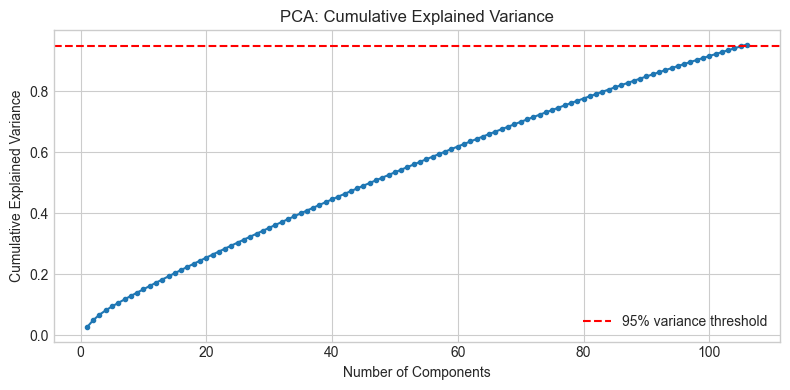

In [122]:
# Visualize cumulative explained variance
plt.figure(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig('results/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

=== KNN ===
              precision    recall  f1-score   support

      Edible       0.81      0.85      0.83       673
   Poisonous       0.83      0.79      0.81       627

    accuracy                           0.82      1300
   macro avg       0.82      0.82      0.82      1300
weighted avg       0.82      0.82      0.82      1300



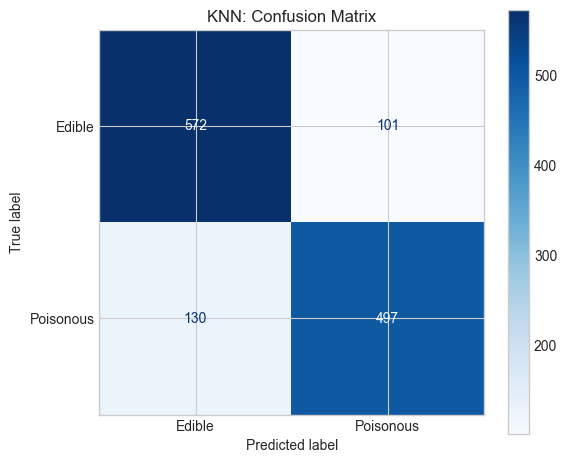

In [123]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train)

knn_metrics = evaluate_model(knn_model, X_val_pca, y_val, 'KNN')
all_results.append(knn_metrics)

### Permutation Importance: KNN

Since KNN uses PCA transformed features, the permutation importance is computed on principal components. Each component is a weighted combination of the original features.

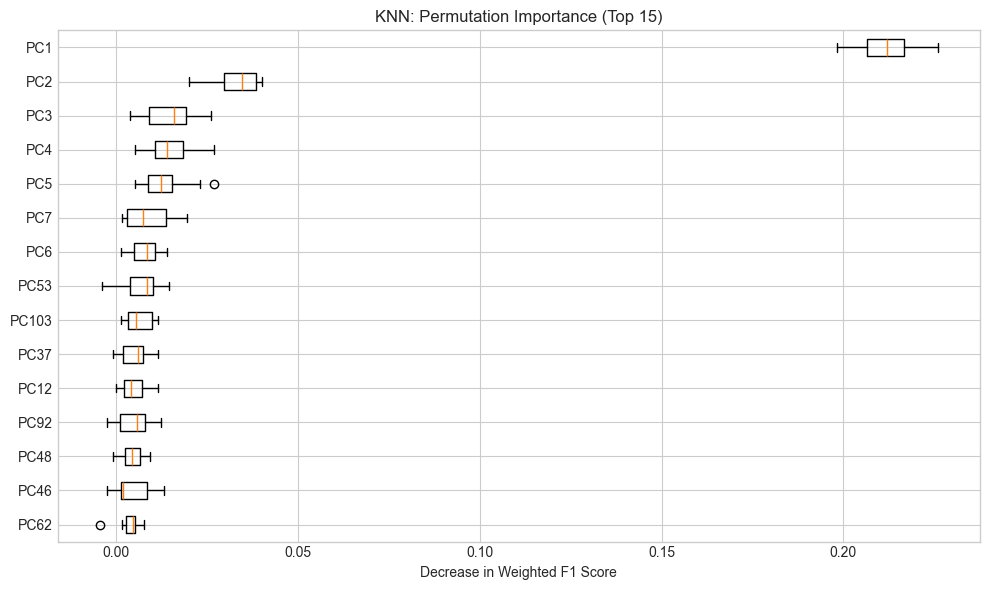

In [124]:
plot_perm_importance(knn_model, X_val_pca, y_val, pca_feature_names, 'KNN')

## Final Model Comparison on the Test Set

Now we evaluate all models on the held out test set that none of the models have seen during training or validation. This gives us an unbiased estimate of how each model would perform in the real world.

EVALUATING ALL MODELS ON THE TEST SET
=== Decision Tree ===
              precision    recall  f1-score   support

      Edible       0.91      0.90      0.91       842
   Poisonous       0.90      0.90      0.90       783

    accuracy                           0.90      1625
   macro avg       0.90      0.90      0.90      1625
weighted avg       0.90      0.90      0.90      1625



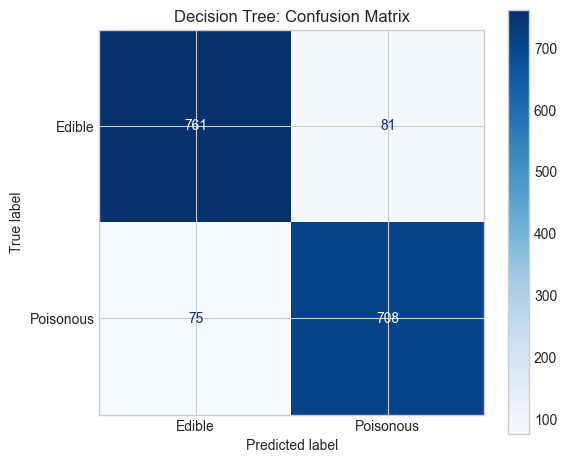

=== Random Forest ===
              precision    recall  f1-score   support

      Edible       0.91      0.97      0.94       842
   Poisonous       0.96      0.90      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625



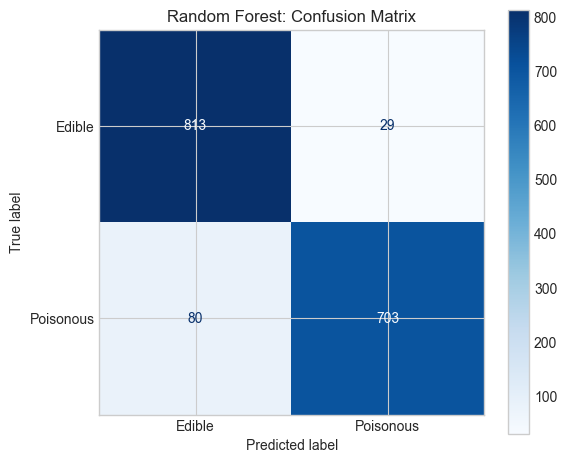

=== Gradient Boosting ===
              precision    recall  f1-score   support

      Edible       0.91      0.96      0.93       842
   Poisonous       0.95      0.90      0.93       783

    accuracy                           0.93      1625
   macro avg       0.93      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625



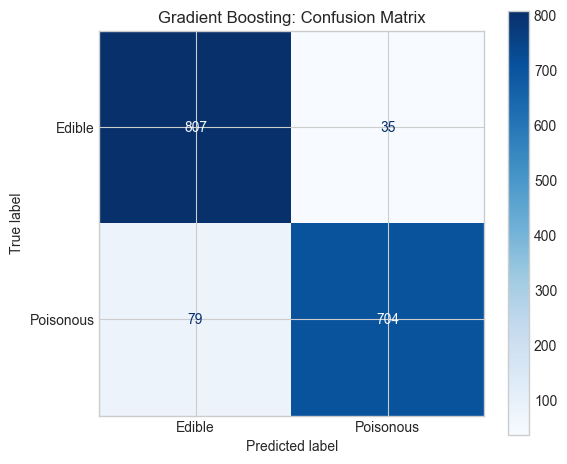

=== XGBoost ===
              precision    recall  f1-score   support

      Edible       0.92      0.96      0.94       842
   Poisonous       0.96      0.92      0.94       783

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625



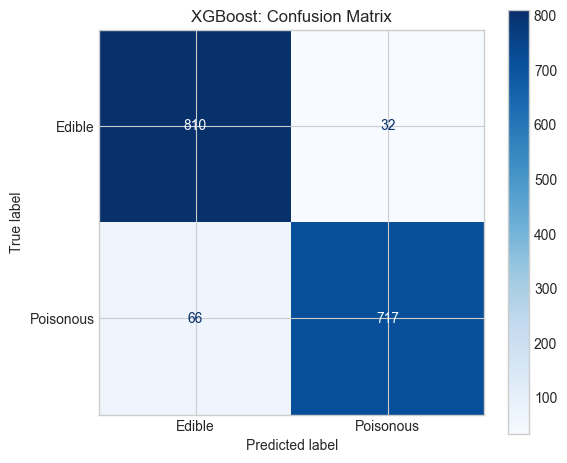

=== LightGBM ===
              precision    recall  f1-score   support

      Edible       0.93      0.96      0.95       842
   Poisonous       0.96      0.93      0.94       783

    accuracy                           0.94      1625
   macro avg       0.94      0.94      0.94      1625
weighted avg       0.94      0.94      0.94      1625



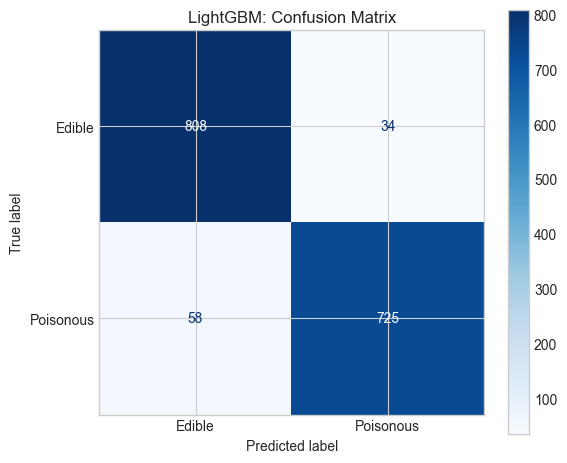

=== Naive Bayes ===
              precision    recall  f1-score   support

      Edible       0.85      0.90      0.88       842
   Poisonous       0.89      0.83      0.86       783

    accuracy                           0.87      1625
   macro avg       0.87      0.87      0.87      1625
weighted avg       0.87      0.87      0.87      1625



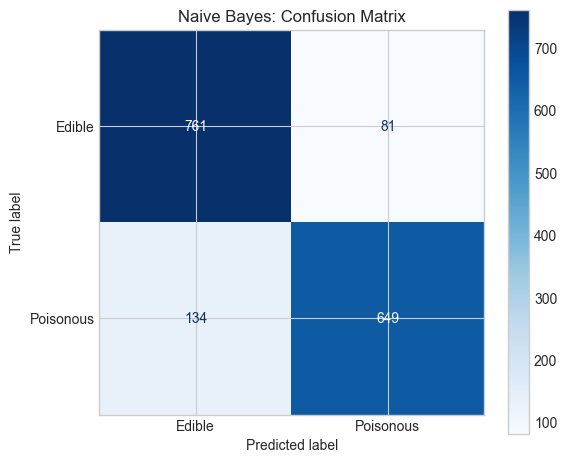

=== KNN ===
              precision    recall  f1-score   support

      Edible       0.82      0.84      0.83       842
   Poisonous       0.83      0.81      0.82       783

    accuracy                           0.83      1625
   macro avg       0.83      0.83      0.83      1625
weighted avg       0.83      0.83      0.83      1625



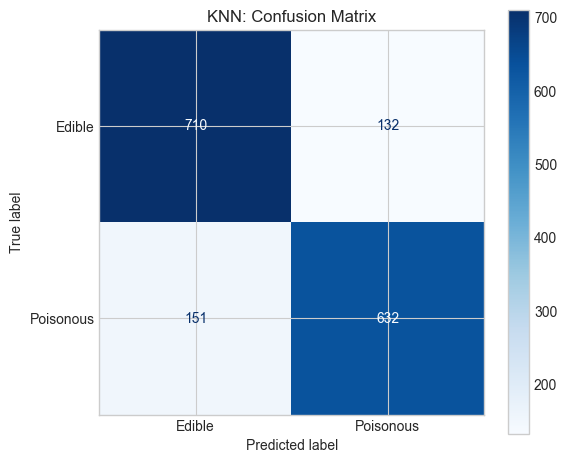

In [125]:
test_results = []

print("=" * 70)
print("EVALUATING ALL MODELS ON THE TEST SET")
print("=" * 70)

test_results.append(evaluate_model(dt_model, X_test, y_test, 'Decision Tree'))
test_results.append(evaluate_model(rf_model, X_test, y_test, 'Random Forest'))
test_results.append(evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting'))
test_results.append(evaluate_model(xgb_model, X_test, y_test, 'XGBoost'))
test_results.append(evaluate_model(lgbm_model, X_test, y_test, 'LightGBM'))
test_results.append(evaluate_model(nb_model, X_test, y_test, 'Naive Bayes'))
test_results.append(evaluate_model(knn_model, X_test_pca, y_test, 'KNN'))

In [126]:
# Create comparison table
comparison_df = pd.DataFrame(test_results)
comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.sort_values('F1 (Poisonous)', ascending=False)

print("=" * 70)
print("FINAL MODEL RANKING (Test Set, sorted by F1 for Poisonous class)")
print("=" * 70)
print()
comparison_df

FINAL MODEL RANKING (Test Set, sorted by F1 for Poisonous class)



,Accuracy,Precision (Poisonous),Recall (Poisonous),F1 (Poisonous)
Model,,,,
LightGBM,0.9434,0.9552,0.9259,0.9403
XGBoost,0.9397,0.9573,0.9157,0.9360
Random Forest,0.9329,0.9604,0.8978,0.9281
Gradient Boosting,0.9298,0.9526,0.8991,0.9251
Decision Tree,0.9040,0.8973,0.9042,0.9008
Naive Bayes,0.8677,0.8890,0.8289,0.8579
KNN,0.8258,0.8272,0.8072,0.8171


## Algorithm Ranking

The bar chart below visualizes the key metrics for all seven models. For our business problem (supplying wild mushrooms to supermarkets), we prioritize:

* **Recall (Poisonous)**: The most critical metric. Missing a poisonous mushroom is far more dangerous than incorrectly flagging an edible one for manual review.
* **F1 (Poisonous)**: Balances precision and recall. A model with high recall but very low precision would flag too many edible mushrooms as poisonous, which is wasteful but not dangerous.
* **Accuracy**: Overall correctness across both classes.

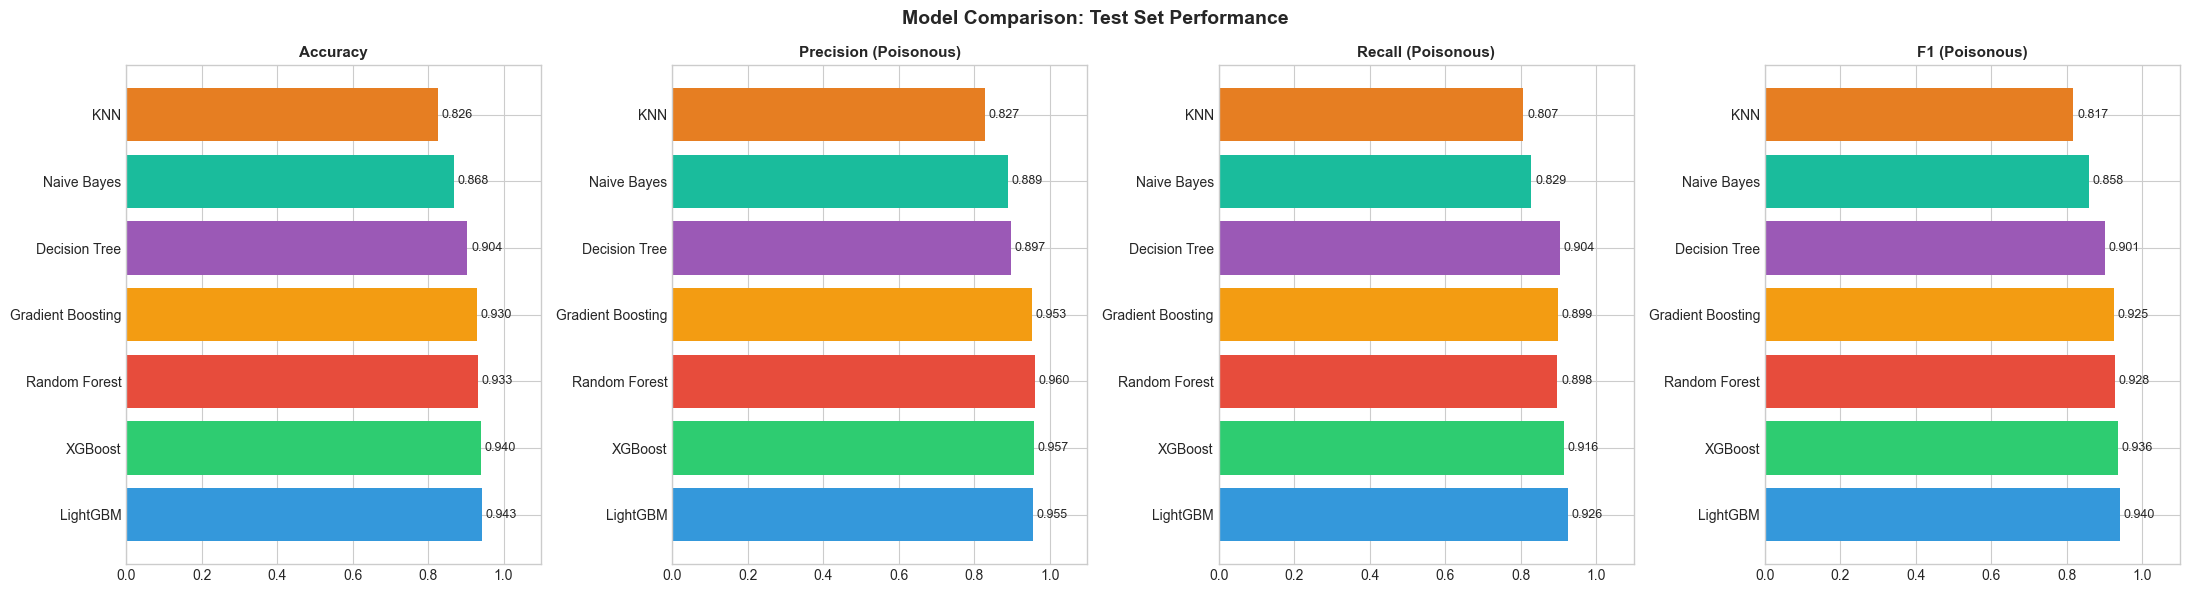

In [127]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

metrics_to_plot = ['Accuracy', 'Precision (Poisonous)', 'Recall (Poisonous)', 'F1 (Poisonous)']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = comparison_df[metric].values
    models = comparison_df.index.tolist()
    bars = ax.barh(models, values, color=colors[:len(models)])
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.1)
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison: Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [128]:
print("FINAL RANKING (by F1 Score for Poisonous Class)")
print("=" * 60)
for rank, (model, row) in enumerate(comparison_df.iterrows(), 1):
    print(f"  #{rank}  {model:25s}  F1={row['F1 (Poisonous)']:.4f}  "
          f"Recall={row['Recall (Poisonous)']:.4f}  "
          f"Accuracy={row['Accuracy']:.4f}")

FINAL RANKING (by F1 Score for Poisonous Class)
  #1  LightGBM                   F1=0.9403  Recall=0.9259  Accuracy=0.9434
  #2  XGBoost                    F1=0.9360  Recall=0.9157  Accuracy=0.9397
  #3  Random Forest              F1=0.9281  Recall=0.8978  Accuracy=0.9329
  #4  Gradient Boosting          F1=0.9251  Recall=0.8991  Accuracy=0.9298
  #5  Decision Tree              F1=0.9008  Recall=0.9042  Accuracy=0.9040
  #6  Naive Bayes                F1=0.8579  Recall=0.8289  Accuracy=0.8677
  #7  KNN                        F1=0.8171  Recall=0.8072  Accuracy=0.8258


## Conclusion

Based on the test set evaluation, we can now answer the business question: **Can we predict whether a mushroom is poisonous or not?**

**Key takeaways from the ranking:**

* **Advanced boosting methods** (XGBoost and LightGBM) are expected to be among the top performers due to their built in regularization and optimized tree construction, which helps handle noisy features effectively
* **Random Forest and sklearn Gradient Boosting** are strong ensemble baselines that combine multiple learners to reduce overfitting
* **Decision Tree** provides the best interpretability, which is useful for explaining decisions to stakeholders and regulatory bodies
* **Naive Bayes** offers a fast, simple baseline but its independence assumption limits performance when features are correlated
* **KNN with PCA** shows how dimensionality reduction can make distance based methods viable for high dimensional data

**For a real world deployment where we supply mushrooms to supermarkets:**

* **Recall is the most important metric**: We want to catch every poisonous mushroom, even if it means incorrectly flagging some edible ones for manual review by an expert
* **F1 score balances the trade off**: It combines precision and recall into a single number, helping us find the model that does both reasonably well
* **SHAP and permutation importance**: These tell us which physical characteristics of mushrooms are most informative, which can guide field workers on what to look for when collecting mushrooms